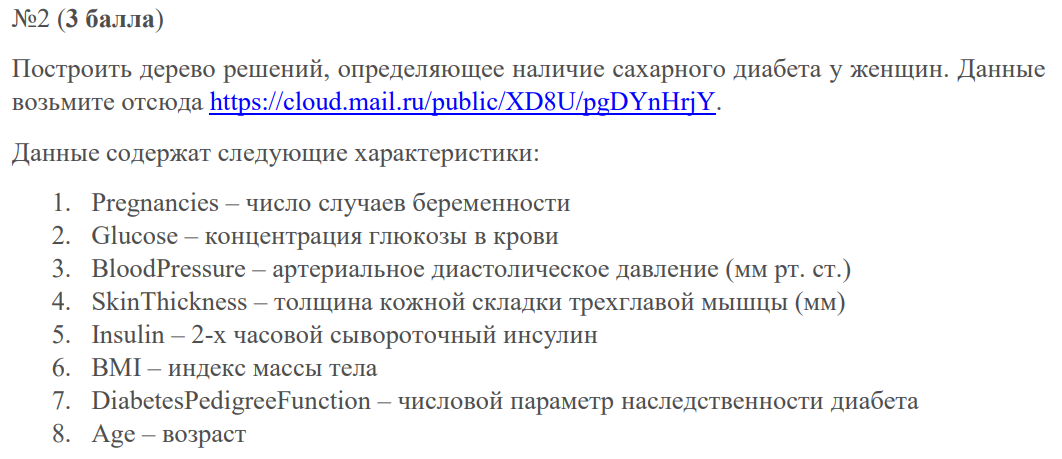
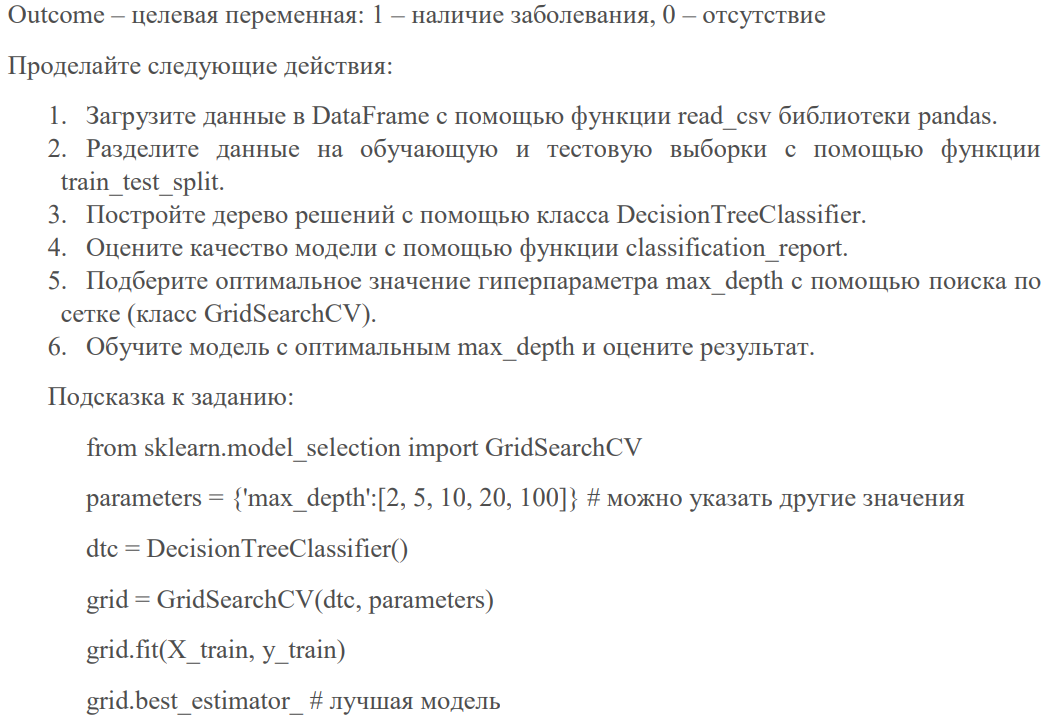

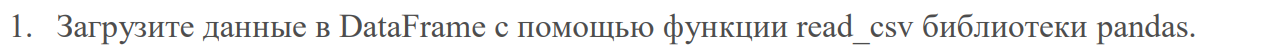

In [23]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
df = pd.read_csv('diabetes.csv', decimal=',')

print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  Unnamed: 9  
0                     0.627   50        1         NaN  
1                     0.351   31        0         NaN  
2                     0.672   32        1         NaN  
3                     0.167   21        0         NaN  
4                     2.288   33        1         NaN  


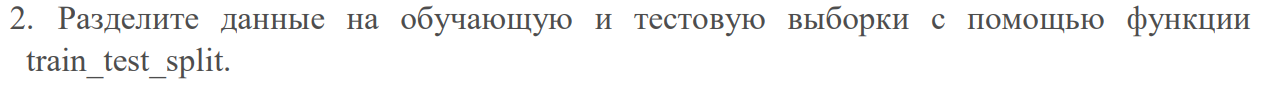

In [24]:
# Отделяем признаки от целевой переменной
feature_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                   'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

X = df[feature_columns]
y = df['Outcome']

print(X.columns.tolist())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Создаем и обучаем
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

# Делаем предсказания
y_pred_default = dt_default.predict(X_test)

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


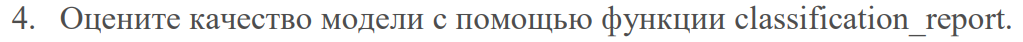

In [25]:
# Выводим детальный отчет о классификации
print("Отчет о классификации для дерева решений (по умолчанию):")
print(classification_report(y_test, y_pred_default, 
                          target_names=['Без диабета', 'С диабетом']))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_default)
print("\nМатрица ошибок (Confusion Matrix):")
print(cm)
print(f"\nТакже известна как:")
print(f"TN (True Negatives):  {cm[0,0]} - правильно предсказали отсутствие диабета")
print(f"FP (False Positives): {cm[0,1]} - ошибка (предсказали диабет, но его нет)")
print(f"FN (False Negatives): {cm[1,0]} - ошибка (не предсказали диабет, но он есть)")
print(f"TP (True Positives):  {cm[1,1]} - правильно предсказали наличие диабета")

Отчет о классификации для дерева решений (по умолчанию):
              precision    recall  f1-score   support

 Без диабета       0.84      0.74      0.78       206
  С диабетом       0.57      0.71      0.63       102

    accuracy                           0.73       308
   macro avg       0.70      0.72      0.71       308
weighted avg       0.75      0.73      0.73       308


Матрица ошибок (Confusion Matrix):
[[152  54]
 [ 30  72]]

Также известна как:
TN (True Negatives):  152 - правильно предсказали отсутствие диабета
FP (False Positives): 54 - ошибка (предсказали диабет, но его нет)
FN (False Negatives): 30 - ошибка (не предсказали диабет, но он есть)
TP (True Positives):  72 - правильно предсказали наличие диабета


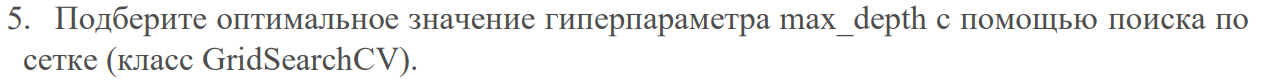

In [26]:
parameters = {'max_depth': [2, 3, 4, 5, 7, 10, 15, 20, None]}

# Создаем объект GridSearchCV для поиска оптимальных параметров
dtc = DecisionTreeClassifier(random_state=42)
grid = GridSearchCV(dtc, parameters, cv=5, scoring='accuracy', n_jobs=-1)

# Обучаем модель
grid.fit(X_train, y_train)

print(f"\nЛучшее значение max_depth: {grid.best_params_['max_depth']}")
print(f"Лучший результат (cross-validation score): {grid.best_score_:.4f}")

# Выводим результаты для всех значений max_depth
results_df = pd.DataFrame(grid.cv_results_)
results_summary = results_df[['param_max_depth', 'mean_test_score', 'std_test_score', 
                              'rank_test_score']].copy()
results_summary.columns = ['max_depth', 'mean_score', 'std_score', 'rank']

print("\nРезультаты для разных значений max_depth:")
print(results_summary.to_string(index=False))



Лучшее значение max_depth: 2
Лучший результат (cross-validation score): 0.7283

Результаты для разных значений max_depth:
max_depth  mean_score  std_score  rank
        2    0.728261   0.016839     1
        3    0.715217   0.024208     3
        4    0.719565   0.023211     2
        5    0.704348   0.038522     4
        7    0.682609   0.039730     9
       10    0.702174   0.023414     5
       15    0.684783   0.026625     8
       20    0.686957   0.024208     6
     None    0.686957   0.024208     6


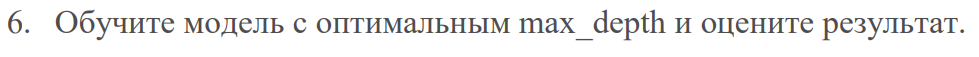

In [27]:
# Получаем лучшую модель из GridSearchCV
best_dt = grid.best_estimator_

# Делаем предсказания на тестовой выборке
y_pred_best = best_dt.predict(X_test)

print("Отчет о классификации для оптимальной модели:")
print(classification_report(y_test, y_pred_best, 
                          target_names=['Без диабета', 'С диабетом']))

# Матрица ошибок для оптимальной модели
cm_best = confusion_matrix(y_test, y_pred_best)
print("\nМатрица ошибок для оптимальной модели:")
print(cm_best)
print(f"\nТN (True Negatives):  {cm_best[0,0]}")
print(f"FP (False Positives): {cm_best[0,1]}")
print(f"FN (False Negatives): {cm_best[1,0]}")
print(f"TP (True Positives):  {cm_best[1,1]}")

Отчет о классификации для оптимальной модели:
              precision    recall  f1-score   support

 Без диабета       0.74      0.94      0.83       206
  С диабетом       0.73      0.34      0.47       102

    accuracy                           0.74       308
   macro avg       0.74      0.64      0.65       308
weighted avg       0.74      0.74      0.71       308


Матрица ошибок для оптимальной модели:
[[193  13]
 [ 67  35]]

ТN (True Negatives):  193
FP (False Positives): 13
FN (False Negatives): 67
TP (True Positives):  35


In [28]:
# Сравниваем модель по умолчанию с оптимальной
print("Сравнение")
print(f"{'Параметр':<40} {'По умолчанию':<15} {'Оптимальная':<15}")
print(f"{'max_depth':<40} {str(dt_default.max_depth):<15} {str(best_dt.max_depth):<15}")
print(f"{'Глубина дерева':<40} {dt_default.get_depth():<15} {best_dt.get_depth():<15}")
print(f"{'Количество листьев':<40} {dt_default.get_n_leaves():<15} {best_dt.get_n_leaves():<15}")
print("-"*70)
print(f"{'Точность на обучающей выборке':<40} {dt_default.score(X_train, y_train):<15.4f} {best_dt.score(X_train, y_train):<15.4f}")
print(f"{'Точность на тестовой выборке':<40} {dt_default.score(X_test, y_test):<15.4f} {best_dt.score(X_test, y_test):<15.4f}")


Сравнение
Параметр                                 По умолчанию    Оптимальная    
max_depth                                None            2              
Глубина дерева                           13              2              
Количество листьев                       82              4              
----------------------------------------------------------------------
Точность на обучающей выборке            1.0000          0.7522         
Точность на тестовой выборке             0.7273          0.7403         
